# 02 — Arm 1: TF-IDF / k-NN Retrieval

Dataset C, AMLH coursework. Validation-only hyperparameter, preprocessing, index-variant,
indexing-scheme, split-design, and baseline-model experiments for the traditional NLP arm. No
test-set cell anywhere in this notebook. All logic lives in `src/amlh`; this notebook only calls
it, displays results, and persists tables to `artefacts/` and figures to `figures/`.

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from amlh import arm1_experiments as ae
from amlh import arm1_tfidf, evaluate, features
from amlh.config import ARTEFACTS_DIR, FIGURES_DIR, SEED, set_seed
from amlh.data import load_train, make_random_split

## 1. Load splits from `artefacts/`

In [2]:
set_seed()

fit = pd.read_csv(ARTEFACTS_DIR / "split_fit.csv")
val = pd.read_csv(ARTEFACTS_DIR / "split_val.csv")
print(f"fit={len(fit)} ({fit.disease.nunique()} classes) | val={len(val)} ({val.disease.nunique()} classes)")

fit=8691 (906 classes) | val=200 (102 classes)


## 2. Hyperparameter grid — class-blob index, variant Q

`ngram_range × sublinear_tf × min_df × stop_words × k` — 80 configs. Selection uses a
one-standard-error rule (`ae.select_within_one_se`), not the raw argmax: with n=200 validation
items, SE ≈ 3.5pp at the top accuracy, so among configs within 1 SE of the best we take the
simplest (lowest k, unigrams, no stop-word removal). `k`'s effect is limited under blob indexing
since each class contributes exactly one row to the index regardless of `k` — reported anyway,
as evidence for §4.2.

In [3]:
grid_Q = ae.run_vectoriser_grid(
    fit, val, "Q",
    ngram_ranges=[(1, 1), (1, 2)],
    sublinear_tf_opts=[False, True],
    min_dfs=[1, 2],
    stop_words_opts=[None, "english"],
    ks=[1, 3, 5, 10, 20],
)
grid_Q.to_csv(ARTEFACTS_DIR / "arm1_grid_Q.csv", index=False)
print(f"{len(grid_Q)} configs run")
grid_Q.sort_values("accuracy", ascending=False).head(10)

80 configs run


,ngram_range,sublinear_tf,min_df,stop_words,k,accuracy,acc_at_5,macro_f1,mrr
47,"(1, 2)",False,1,english,5,0.835,0.905,0.710753,0.859333
49,"(1, 2)",False,1,english,20,0.835,0.905,0.710753,0.862472
46,"(1, 2)",False,1,english,3,0.835,0.890,0.710753,0.855833
48,"(1, 2)",False,1,english,10,0.835,0.905,0.710753,0.862056
45,"(1, 2)",False,1,english,1,0.835,0.835,0.710753,0.835000
26,"(1, 1)",True,1,english,3,0.825,0.905,0.684252,0.860833
25,"(1, 1)",True,1,english,1,0.825,0.825,0.684252,0.825000
68,"(1, 2)",True,1,english,10,0.825,0.910,0.683202,0.864500
67,"(1, 2)",True,1,english,5,0.825,0.910,0.683202,0.862833
66,"(1, 2)",True,1,english,3,0.825,0.900,0.683202,0.860833


In [4]:
argmax_row_Q = grid_Q.loc[grid_Q["accuracy"].idxmax()]
selected_row_Q = ae.select_within_one_se(grid_Q, n_val=len(val))
print("argmax row:")
print(argmax_row_Q)
print()
print("selected (simplest within 1 SE) row:")
print(selected_row_Q)

best_vec_kwargs = {
    "ngram_range": selected_row_Q["ngram_range"],
    "sublinear_tf": selected_row_Q["sublinear_tf"],
    "min_df": selected_row_Q["min_df"],
    "stop_words": selected_row_Q["stop_words"],
}
best_k = int(selected_row_Q["k"])
print()
print("best_vec_kwargs (Q, from step 2):", best_vec_kwargs)
print("best_k (Q, from step 2):", best_k)

argmax row:
ngram_range       (1, 2)
sublinear_tf       False
min_df                 1
stop_words       english
k                      1
accuracy           0.835
acc_at_5           0.835
macro_f1        0.710753
mrr                0.835
Name: 45, dtype: object

selected (simplest within 1 SE) row:
ngram_range       (1, 1)
sublinear_tf       False
min_df                 1
stop_words          None
k                      1
accuracy            0.82
acc_at_5            0.82
macro_f1        0.672868
mrr                 0.82
Name: 0, dtype: object

best_vec_kwargs (Q, from step 2): {'ngram_range': (1, 1), 'sublinear_tf': np.False_, 'min_df': np.int64(1), 'stop_words': None}
best_k (Q, from step 2): 1


## 3. Preprocessing ablation at the best grid config

`raw` / `lemma_stop` (spaCy lemmatisation + stop-word removal) / `lemma_only` (lemmatisation, stop
words kept), at variant Q and the selected vectoriser config/`k` from step 2.

In [5]:
preprocessing_ablation = ae.run_preprocessing_ablation(fit, val, best_vec_kwargs, best_k)
preprocessing_ablation.to_csv(ARTEFACTS_DIR / "arm1_preprocessing_ablation.csv", index=False)
preprocessing_ablation

,preprocessing,accuracy,acc_at_5,macro_f1,mrr
0,raw,0.820,0.820,0.672868,0.820
1,lemma_stop,0.805,0.805,0.650000,0.805
2,lemma_only,0.825,0.825,0.678036,0.825


In [6]:
# Same within-1-SE-prefer-simplest rule as the vectoriser grid: don't pick lemmatisation
# on a margin the 200-item hold-out can't actually resolve.
best_acc_ablation = preprocessing_ablation["accuracy"].max()
se_ablation = (best_acc_ablation * (1 - best_acc_ablation) / len(val)) ** 0.5
raw_acc = preprocessing_ablation.loc[preprocessing_ablation["preprocessing"] == "raw", "accuracy"].item()

if raw_acc >= best_acc_ablation - se_ablation:
    best_preprocessing = "raw"
else:
    best_preprocessing = preprocessing_ablation.loc[preprocessing_ablation["accuracy"].idxmax(), "preprocessing"]

print(f"best accuracy: {best_acc_ablation:.3f} (SE={se_ablation:.3f}) | raw accuracy: {raw_acc:.3f}")
print("selected preprocessing (prefer raw within 1 SE):", best_preprocessing)

best accuracy: 0.825 (SE=0.027) | raw accuracy: 0.820
selected preprocessing (prefer raw within 1 SE): raw


## 4. Index variants Q / QL / QLA / QLAD

`QLAD` needs the NHS class documents — confirm full coverage over the fit split's disease
universe before using it.

In [7]:
coverage = features.doc_coverage(fit["disease"].unique())
print(json.dumps(coverage, indent=2))
assert coverage["n_found"] == coverage["n_total"] == 906, "expected full 906/906 NHS doc coverage"


{
  "n_total": 906,
  "n_found": 906,
  "missing": []
}


In [8]:
index_variants = ae.run_index_variant_comparison(
    fit, val, ["Q", "QL", "QLA", "QLAD"], best_vec_kwargs, best_k
)
index_variants.to_csv(ARTEFACTS_DIR / "arm1_index_variants.csv", index=False)
index_variants

,variant,accuracy,acc_at_5,macro_f1,mrr
0,Q,0.82,0.82,0.672868,0.82
1,QL,0.82,0.82,0.670256,0.82
2,QLA,0.82,0.82,0.672917,0.82
3,QLAD,0.82,0.82,0.683069,0.82


In [9]:
best_variant = index_variants.loc[index_variants["accuracy"].idxmax(), "variant"]
print("best variant by validation accuracy:", best_variant)

best variant by validation accuracy: Q


### 4b. Variant-specific vectoriser re-check

Blob length differs enormously by variant (short questions vs long NHS prose), so the step-2
optimum — tuned on variant Q only — may not transfer to `best_variant`. Re-run the vectoriser
grid restricted to `best_variant` and re-select within 1 SE; if the winner differs from step 2,
use the variant-specific winner for everything downstream.

In [10]:
grid_variant = ae.run_vectoriser_grid(
    fit, val, best_variant,
    ngram_ranges=[(1, 1), (1, 2)],
    sublinear_tf_opts=[False, True],
    min_dfs=[1, 2],
    stop_words_opts=[None, "english"],
    ks=[1, 3, 5, 10, 20],
)
grid_variant.to_csv(ARTEFACTS_DIR / f"arm1_grid_{best_variant}.csv", index=False)
selected_row_variant = ae.select_within_one_se(grid_variant, n_val=len(val))
print(selected_row_variant)

ngram_range       (1, 1)
sublinear_tf       False
min_df                 1
stop_words          None
k                      1
accuracy            0.82
acc_at_5            0.82
macro_f1        0.672868
mrr                 0.82
Name: 0, dtype: object


In [11]:
variant_vec_kwargs = {
    "ngram_range": selected_row_variant["ngram_range"],
    "sublinear_tf": selected_row_variant["sublinear_tf"],
    "min_df": selected_row_variant["min_df"],
    "stop_words": selected_row_variant["stop_words"],
}
variant_k = int(selected_row_variant["k"])

config_unchanged = variant_vec_kwargs == best_vec_kwargs and variant_k == best_k
print("variant-specific config matches step-2 config:", config_unchanged)

if not config_unchanged:
    print("Using the variant-specific winner downstream (discrepancy noted for §2.5).")
    best_vec_kwargs = variant_vec_kwargs
    best_k = variant_k

print("final best_vec_kwargs:", best_vec_kwargs)
print("final best_k:", best_k)

variant-specific config matches step-2 config: True
final best_vec_kwargs: {'ngram_range': (1, 1), 'sublinear_tf': np.False_, 'min_df': np.int64(1), 'stop_words': None}
final best_k: 1


## 5. Indexing scheme — class-blob vs additive-per-row

A designed comparison for §4.2, not a footnote: does spreading the index over one row per
training example (rather than one blob per class) change retrieval accuracy at the winning
variant and vectoriser config?

In [12]:
indexing_scheme = ae.run_indexing_scheme_comparison(fit, val, best_variant, best_vec_kwargs, best_k)
indexing_scheme.to_csv(ARTEFACTS_DIR / "arm1_indexing_scheme.csv", index=False)
indexing_scheme

,scheme,n_index_rows,accuracy,acc_at_5,macro_f1,mrr
0,class_blob,906,0.82,0.82,0.672868,0.82
1,additive_per_row,8691,0.64,0.64,0.432091,0.64


In [13]:
best_scheme = indexing_scheme.loc[indexing_scheme["accuracy"].idxmax(), "scheme"]
print("best indexing scheme by validation accuracy:", best_scheme)

best indexing scheme by validation accuracy: class_blob


## 6. Split-robustness check — stratified vs unstratified

Rerun the top-3 variant-Q grid configs (step 2) under an unstratified `make_random_split`
(NLP1/NLP3 pattern), across 3 random seeds, and check whether the config ranking survives a
different split design. **Absolute accuracy is not comparable across split designs** — fit/val
composition differs — only whether the *ranking* of the three configs is preserved is the thing
under test here.

In [14]:
top3_configs = (
    grid_Q.sort_values("accuracy", ascending=False)
    .head(3)[["ngram_range", "sublinear_tf", "min_df", "stop_words", "k"]]
    .to_dict("records")
)
for i, cfg in enumerate(top3_configs, start=1):
    print(i, cfg)

train_full = load_train()
split_robustness = ae.run_split_robustness(train_full, top3_configs, variant="Q", seeds=(42, 43, 44))
split_robustness.to_csv(ARTEFACTS_DIR / "arm1_split_robustness.csv", index=False)
split_robustness

1 {'ngram_range': (1, 2), 'sublinear_tf': False, 'min_df': 1, 'stop_words': 'english', 'k': 5}
2 {'ngram_range': (1, 2), 'sublinear_tf': False, 'min_df': 1, 'stop_words': 'english', 'k': 20}
3 {'ngram_range': (1, 2), 'sublinear_tf': False, 'min_df': 1, 'stop_words': 'english', 'k': 3}


,config_rank,seed,ngram_range,sublinear_tf,min_df,stop_words,k,accuracy,acc_at_5,macro_f1,mrr
0,1,42,"(1, 2)",False,1,english,5,0.800,0.895,0.709195,0.838500
1,2,42,"(1, 2)",False,1,english,20,0.800,0.900,0.709195,0.843200
2,3,42,"(1, 2)",False,1,english,3,0.800,0.880,0.709195,0.835000
3,1,43,"(1, 2)",False,1,english,5,0.790,0.895,0.658610,0.830833
4,2,43,"(1, 2)",False,1,english,20,0.790,0.895,0.658610,0.834185
5,3,43,"(1, 2)",False,1,english,3,0.790,0.855,0.658610,0.820833
6,1,44,"(1, 2)",False,1,english,5,0.785,0.890,0.693651,0.826750
7,2,44,"(1, 2)",False,1,english,20,0.785,0.890,0.693651,0.829869
8,3,44,"(1, 2)",False,1,english,3,0.785,0.860,0.693552,0.820000


In [15]:
stratified_ranking = (
    grid_Q.sort_values("accuracy", ascending=False).head(3)["accuracy"].reset_index(drop=True)
)
mean_by_rank = split_robustness.groupby("config_rank")["accuracy"].mean()
print("stratified-split accuracy, top 3 configs (rank order):")
print(stratified_ranking.to_string())
print()
print("mean unstratified-split accuracy across 3 seeds, by config_rank:")
print(mean_by_rank.to_string())
print()
ranking_preserved = list(mean_by_rank.sort_values(ascending=False).index) == list(mean_by_rank.index)
print("config ranking order preserved under the random split (by mean accuracy):", ranking_preserved)

stratified-split accuracy, top 3 configs (rank order):
0    0.835
1    0.835
2    0.835

mean unstratified-split accuracy across 3 seeds, by config_rank:
config_rank
1    0.791667
2    0.791667
3    0.791667

config ranking order preserved under the random split (by mean accuracy): True


## 7. Supervised baselines — LinearSVC / LogisticRegression / RandomForest

Per-row (not blob) TF-IDF classification at the best vectoriser config, contrasting learned
decision boundaries against neighbour matching under ~10 examples per class. The RandomForest
baseline follows the course pattern in `NLP1_word_semantics_solution.ipynb`, which evaluates a
`RandomForestClassifier` over TF-IDF features via `classification_report`.

In [16]:
supervised_baselines = ae.run_supervised_baselines(fit, val, best_vec_kwargs)
supervised_baselines.to_csv(ARTEFACTS_DIR / "arm1_supervised_baselines.csv", index=False)
supervised_baselines

,model,accuracy,acc_at_5,macro_f1,mrr
0,svc,0.795,0.910,0.622886,0.849137
1,logreg,0.705,0.825,0.541487,0.762068
2,random_forest,0.790,0.910,0.627068,0.843930


## 8. Accuracy–coverage curve

Under similarity thresholding on the best overall k-NN configuration (best variant / vectoriser
config / k / indexing scheme): as the abstention threshold rises, coverage falls and the accuracy
of the remaining, retained predictions should rise. Relevant to the healthcare discussion of
abstention as a safety mechanism (§4.3).

In [17]:
if best_scheme == "class_blob":
    index_texts, index_labels = features.build_index(fit, best_variant)
else:
    index_texts, index_labels = features.build_index_additive(fit, best_variant)

ranked, top_sim = arm1_tfidf.knn_rank(
    index_texts, index_labels, val["question"].tolist(), best_k, best_vec_kwargs
)
gold = val["disease"].tolist()

thresholds = [round(0.05 * i, 2) for i in range(21)]  # 0.00 .. 1.00
coverage_curve = evaluate.accuracy_coverage_curve(ranked, gold, top_sim, thresholds)
coverage_curve.to_csv(ARTEFACTS_DIR / "arm1_coverage_curve.csv", index=False)
coverage_curve

,threshold,coverage,n_covered,accuracy
0,0.00,1.000,200,0.820000
1,0.05,1.000,200,0.820000
2,0.10,1.000,200,0.820000
3,0.15,0.985,197,0.822335
4,0.20,0.985,197,0.822335
5,0.25,0.975,195,0.830769
6,0.30,0.935,187,0.866310
7,0.35,0.920,184,0.875000
8,0.40,0.885,177,0.892655
9,0.45,0.830,166,0.903614


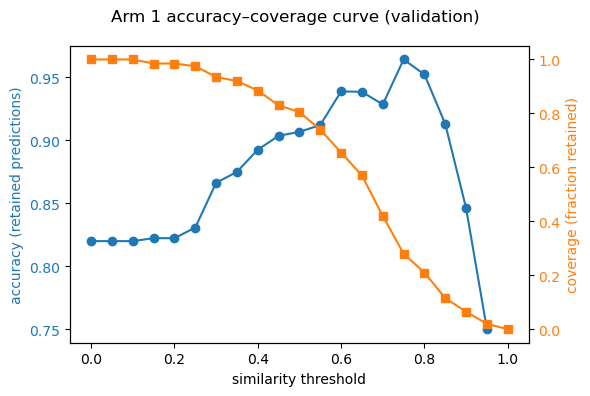

In [18]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(coverage_curve["threshold"], coverage_curve["accuracy"], marker="o", color="tab:blue", label="accuracy")
ax1.set_xlabel("similarity threshold")
ax1.set_ylabel("accuracy (retained predictions)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(coverage_curve["threshold"], coverage_curve["coverage"], marker="s", color="tab:orange", label="coverage")
ax2.set_ylabel("coverage (fraction retained)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle("Arm 1 accuracy–coverage curve (validation)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig4_coverage_curve.png", dpi=150)
plt.show()

## 9. Freeze Arm 1 hyperparameters into `config.py`

Values assembled from the DataFrames computed above — printed here, then copied into
`src/amlh/config.py`'s `HYPERPARAMETERS` Arm 1 fields as a follow-up source edit (not hand-typed
numbers). These fields describe the winning k-NN pipeline only — the LinearSVC/LogReg/RandomForest
and additive-per-row results above are comparison points for the report, not carried forward
into Arm 3's shortlist.

In [19]:
frozen_arm1_hyperparameters = {
    "ngram_range": tuple(int(x) for x in best_vec_kwargs["ngram_range"]),
    "min_df": int(best_vec_kwargs["min_df"]),
    "max_df": 1.0,
    "sublinear_tf": bool(best_vec_kwargs["sublinear_tf"]),
    "stop_words": best_vec_kwargs["stop_words"],
    "lemmatise": best_preprocessing != "raw",
    "index_variant": str(best_variant),
    "index_scheme": str(best_scheme),
    "k_neighbors": int(best_k),
}
print(json.dumps({**frozen_arm1_hyperparameters, "ngram_range": list(frozen_arm1_hyperparameters["ngram_range"])}, indent=2))

{
  "ngram_range": [
    1,
    1
  ],
  "min_df": 1,
  "max_df": 1.0,
  "sublinear_tf": false,
  "stop_words": null,
  "lemmatise": false,
  "index_variant": "Q",
  "index_scheme": "class_blob",
  "k_neighbors": 1
}
